In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# load mlp output
mlp_output = np.load("../outputs/test_results-2025_07_01_19_03_57.npz")
print(mlp_output.keys())

KeysView(NpzFile '../outputs/test_results-2025_07_01_19_03_57.npz' with keys: inputs, target, outputs)


In [41]:
# Remove first dimension by taking first element since batch size was 1
inputs = mlp_output["inputs"]
targets = mlp_output["target"]
outputs = mlp_output["outputs"]

print("\nAfter reshaping:")
print("Inputs shape: ", inputs.shape)
print("Targets shape: ", targets.shape) 
print("Outputs shape: ", outputs.shape)



After reshaping:
Inputs shape:  (995, 8000)
Targets shape:  (995, 8000)
Outputs shape:  (995, 8000)


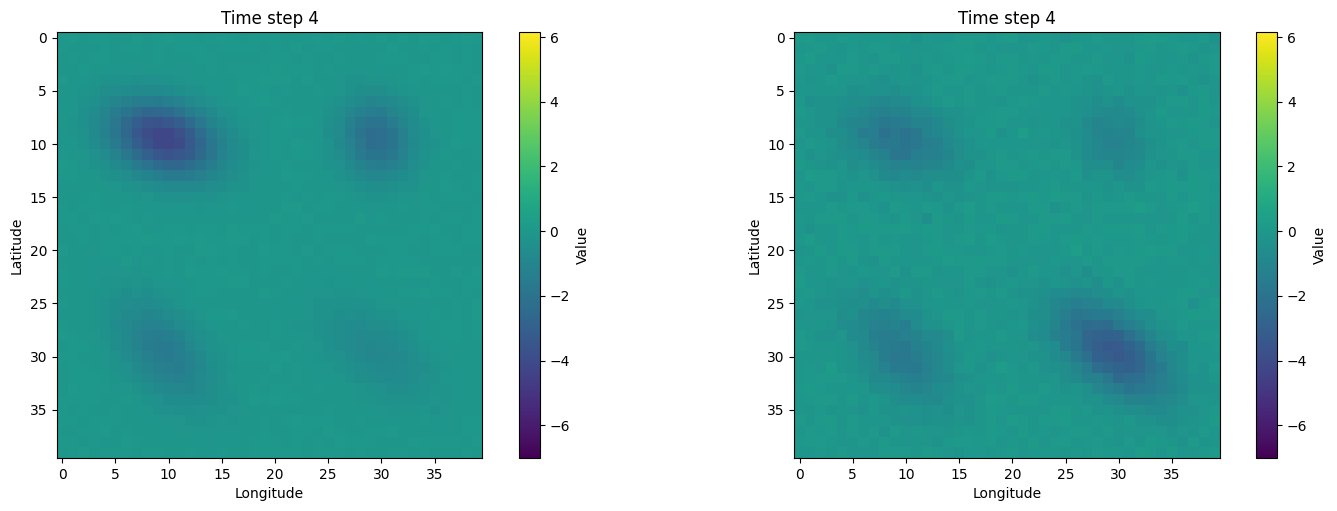

In [47]:
# Reshape targets to 40x40x5
targets_reshaped = targets[0].reshape(5, 40, 40)
outputs_reshaped = outputs[0].reshape(5, 40, 40)

# Get min and max values across both arrays for consistent color scaling
vmin = min(targets_reshaped.min(), outputs_reshaped.min())
vmax = max(targets_reshaped.max(), outputs_reshaped.max())

# Create figure with subplots for target and output comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Initialize heatmaps with same vmin/vmax
im1 = ax1.imshow(targets_reshaped[0, :, :], cmap='viridis', vmin=vmin, vmax=vmax)
im2 = ax2.imshow(outputs_reshaped[0, :, :], cmap='viridis', vmin=vmin, vmax=vmax)

# Add colorbars to both plots with same scale
plt.colorbar(im1, ax=ax1, label='Value')
plt.colorbar(im2, ax=ax2, label='Value')

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()

# Animation update function
def update(frame):

    im1.set_array(targets_reshaped[frame, :, :])
    im2.set_array(outputs_reshaped[frame, :, :])
    ax1.set_title(f'Time step {frame}')
    ax2.set_title(f'Time step {frame}')
    return [im1, im2]

from matplotlib.animation import FuncAnimation

# Create animation
anim = FuncAnimation(fig, update, frames=5, interval=1000, repeat=True, blit=True)

from IPython.display import HTML
HTML(anim.to_jshtml())


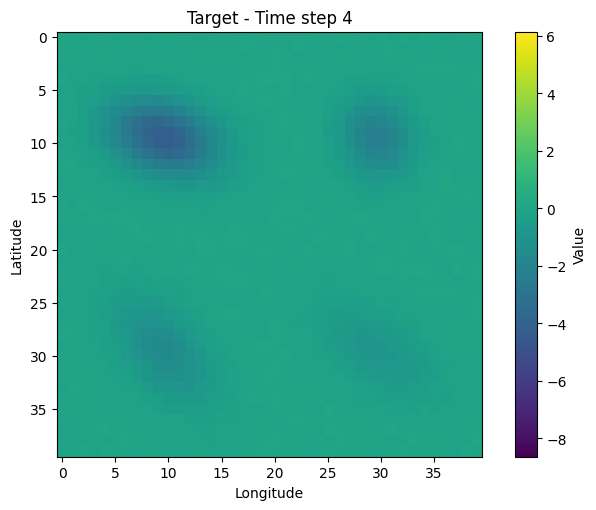

In [44]:
# Reshape targets to 40x40x5
targets_reshaped = targets[0].reshape(5, 40, 40)
inputs_reshaped = inputs[0].reshape(5, 40, 40)

# Concatenate along time dimension
combined_data = np.concatenate([inputs_reshaped, targets_reshaped], axis=2)

# Get min and max values for consistent color scaling
vmin = combined_data.min()
vmax = combined_data.max()

# Create figure with single plot
fig, ax = plt.subplots(figsize=(7, 5))

# Initialize heatmap
im = ax.imshow(outputs_reshaped[0, :, :], cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label='Value')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()

# Animation update function
def update(frame):
    if frame < 5:
        data = inputs_reshaped[frame, :, :]
        title = f'Input - Time step {frame}'
    else:
        data = targets_reshaped[frame-5, :, :]
        title = f'Target - Time step {frame-5}'
        
    im.set_array(data)
    ax.set_title(title)
    return [im]

from matplotlib.animation import FuncAnimation

# Create animation with 10 frames (5 outputs + 5 targets)
anim = FuncAnimation(fig, update, frames=10, interval=1000, repeat=True, blit=True)

from IPython.display import HTML
HTML(anim.to_jshtml())
